# 第一周 EDA — 技术文档翻译数据集
目标：了解数据分布、发现质量问题、为清洗做准备

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import collections

def setup_plot_style():
    """统一 matplotlib 绘图样式（中文字体等），供所有绘图 cell 复用，避免重复设置"""
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac
    plt.rcParams['axes.unicode_minus'] = False

setup_plot_style()

# 读取数据
df = pd.read_csv('data/raw/tech_document_translation_data.csv', encoding='utf-8-sig')

print('总行数:', len(df))
print('列名:', df.columns.tolist())
df.head(3)

总行数: 10000
列名: ['topic', 'chinese', 'japanese', 'indonesian']


,topic,chinese,japanese,indonesian
0,API接口调用,部署Pod前，需先完成API接口调用和批量处理的准备工作。,ポッドをデプロイする前に、API接口调用と批量处理の準備作業を完了する必要があります。,"Sebelum menyebarkan Pod, perlu menyelesaikan p..."
1,API接口调用,镜像是API接口调用中的核心组件，用于实现资源调度功能。,イメージはAPI接口调用のコアコンポーネントであり、资源调度機能を実現するために使用されます。,gambar adalah komponen inti dalam API接口调用 yang...
2,云计算基础,算力支持云计算基础和安全防护两种模式，满足不同业务需求。,算力は云计算基础と安全防护の2つのモードをサポートし、異なる業務ニーズを満たします。,"算力 mendukung dua mode yaitu 云计算基础 dan 安全防护, me..."


topic
对象存储使用     1064
容器服务部署     1048
监控告警配置     1023
云计算基础      1013
云服务器操作     1000
安全防护设置      990
负载均衡配置      988
故障排查指南      976
数据库运维       965
API接口调用     933
Name: count, dtype: int64


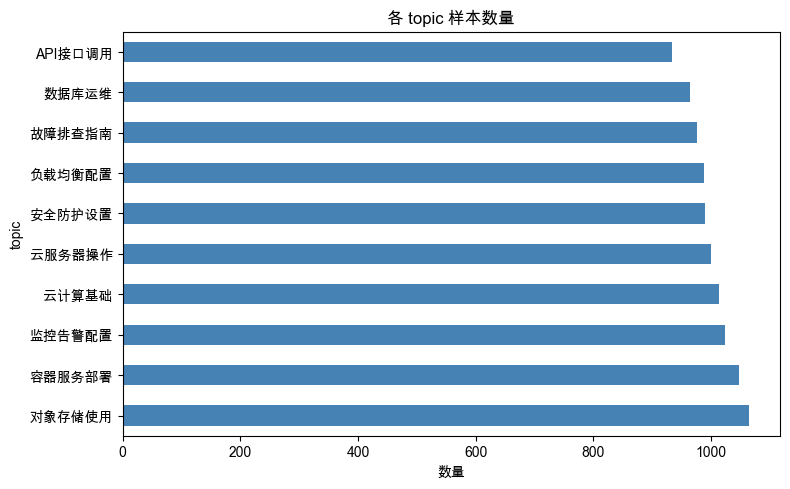

In [2]:
# === Cell 2: topic 分布 ===
# 看看每个领域有多少条数据，是否均衡
topic_counts = df['topic'].value_counts()
print(topic_counts)

topic_counts.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('各 topic 样本数量')
plt.xlabel('数量')
plt.tight_layout()
plt.savefig('logs/topic_distribution.png', dpi=120)
plt.show()

        len_zh   len_ja   len_id
count  10000.0  10000.0  10000.0
mean      29.1     44.8     88.6
std        2.7      4.7     11.4
min       24.0     34.0     60.0
25%       27.0     42.0     83.0
50%       29.0     44.0     89.0
75%       31.0     48.0     95.0
max       39.0     58.0    124.0


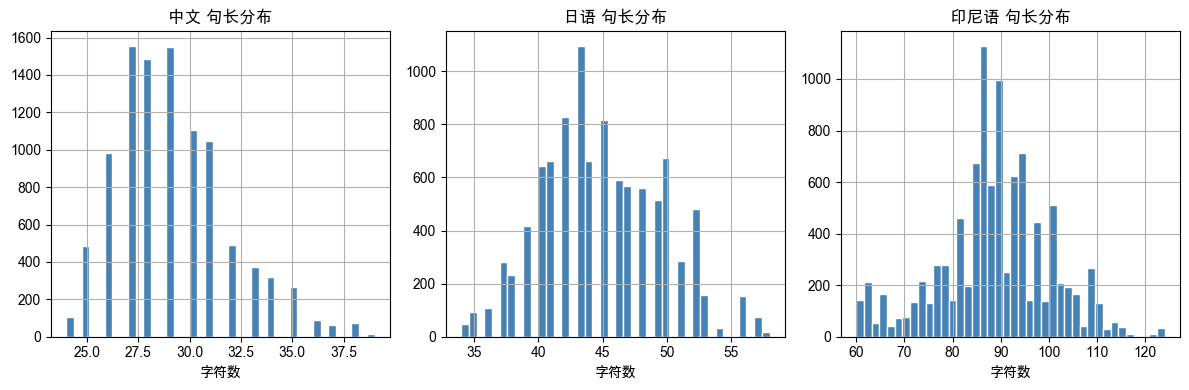

In [3]:
# === Cell 3: 句长分布 ===
# 看三种语言的句子长度，判断有没有异常短/长的样本
df['len_zh'] = df['chinese'].str.len()
df['len_ja'] = df['japanese'].str.len()
df['len_id'] = df['indonesian'].str.len()

print(df[['len_zh', 'len_ja', 'len_id']].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, lang in zip(axes, ['len_zh', 'len_ja', 'len_id'], ['中文', '日语', '印尼语']):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{lang} 句长分布')
    ax.set_xlabel('字符数')
plt.tight_layout()
plt.savefig('logs/sentence_length.png', dpi=120)
plt.show()

In [4]:
# === Cell 4: 混语检测 ===
# 核心问题：日语/印尼语里有多少中文字符没被翻译？
# 用正则检测 CJK 字符（\u4e00-\u9fff）在非中文列里出现的比例

def chinese_char_ratio(text):
    """计算文本中中文字符占比"""
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    zh_chars = re.findall(r'[\u4e00-\u9fff]', text)
    return len(zh_chars) / len(text)

df['zh_ratio_in_ja'] = df['japanese'].apply(chinese_char_ratio)
df['zh_ratio_in_id'] = df['indonesian'].apply(chinese_char_ratio)

# 设定阈值：中文占比 > 5% 视为混语问题样本
threshold = 0.05
ja_mixed = (df['zh_ratio_in_ja'] > threshold).sum()
id_mixed = (df['zh_ratio_in_id'] > threshold).sum()

print(f'日语中混语样本数: {ja_mixed} / {len(df)}  ({ja_mixed/len(df)*100:.1f}%)')
print(f'印尼语中混语样本数: {id_mixed} / {len(df)}  ({id_mixed/len(df)*100:.1f}%)')
print()

# 方法适用性说明：
# - 印尼语用拉丁字母，出现 CJK 字符必然是未翻译残留 → 该指标对印尼语可靠
# - 日语本身含汉字（関連、障害 都是正常日文），该占比把正常日文汉字也计入，
#   只能说明"含汉字多"，无法区分正常日文和未翻译中文 → 日语的可靠检测见 Cell 4.2 专项分析
print('日语混语最严重的5条（注意 zh_ratio 含正常日文汉字，仅作参考）:')
df.nlargest(5, 'zh_ratio_in_ja')[['topic', 'chinese', 'japanese', 'zh_ratio_in_ja']]

日语中混语样本数: 10000 / 10000  (100.0%)
印尼语中混语样本数: 10000 / 10000  (100.0%)

日语混语最严重的5条（注意 zh_ratio 含正常日文汉字，仅作参考）:


,topic,chinese,japanese,zh_ratio_in_ja
249,对象存储使用,排查存储类型相关故障时，应优先检查对象存储使用和批量处理。,存储类型関連の障害を調査する場合、对象存储使用と批量处理を優先的に確認すべきです。,0.658537
362,对象存储使用,排查生命周期相关故障时，应优先检查对象存储使用和资源调度。,生命周期関連の障害を調査する場合、对象存储使用と资源调度を優先的に確認すべきです。,0.658537
426,对象存储使用,排查存储类型相关故障时，应优先检查对象存储使用和批量处理。,存储类型関連の障害を調査する場合、对象存储使用と批量处理を優先的に確認すべきです。,0.658537
435,容器服务部署,排查容器网络相关故障时，应优先检查容器服务部署和故障恢复。,容器网络関連の障害を調査する場合、容器服务部署と故障恢复を優先的に確認すべきです。,0.658537
544,对象存储使用,排查存储类型相关故障时，应优先检查对象存储使用和性能监控。,存储类型関連の障害を調査する場合、对象存储使用と性能监控を優先的に確認すべきです。,0.658537


印尼语译文中共发现 35 个独立未翻译术语，总计出现 23029 次

频率 Top 15:
  故障恢复: 1712
  数据存储: 1692
  安全防护: 1678
  性能监控: 1644
  批量处理: 1638
  资源调度: 1636
  对象存储使用: 1064
  容器服务部署: 1048
  监控告警配置: 1023
  云计算基础: 1013
  云服务器操作: 1000
  安全防护设置: 990
  负载均衡配置: 988
  故障排查指南: 976
  数据库运维: 965


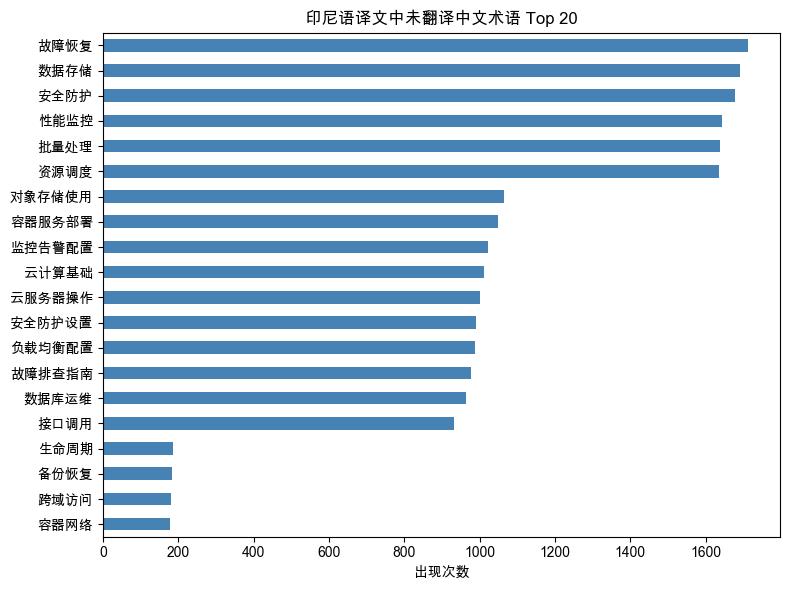

In [5]:
# === Cell 4.1: 未翻译中文术语提取 ===
# Cell 4 只回答了"多少样本有混语"，这里进一步回答"具体是哪些术语没被翻译"
# —— 这份术语清单（含频率）是后续构建术语表、做批量替换的直接输入
# 从印尼语提取：印尼语用拉丁字母，提取到的连续汉字串一定是未翻译残留，零误报

def extract_chinese_terms(text):
    """提取文本中长度 2-10 的连续汉字串（视为疑似未翻译术语）"""
    if not isinstance(text, str):
        return []
    return re.findall(r'[\u4e00-\u9fff]{2,10}', text)

id_term_counter = collections.Counter()
for text in df['indonesian']:
    id_term_counter.update(extract_chinese_terms(text))

print(f'印尼语译文中共发现 {len(id_term_counter)} 个独立未翻译术语，总计出现 {sum(id_term_counter.values())} 次')
print()
print('频率 Top 15:')
for term, cnt in id_term_counter.most_common(15):
    print(f'  {term}: {cnt}')

# 注意：存在嵌套术语（如"安全防护"与"安全防护设置"分别计数），
# 后续替换时需按"长词优先"处理，避免短词先匹配打断长词

# 可视化 Top 20
top_terms = pd.Series(dict(id_term_counter.most_common(20)))
top_terms.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('印尼语译文中未翻译中文术语 Top 20')
plt.xlabel('出现次数')
plt.tight_layout()
plt.savefig('logs/untranslated_terms_top20.png', dpi=120)
plt.show()

In [6]:
# === Cell 4.2: 日语混语专项分析 ===
# 问题：日语本身使用汉字，"中文字符占比"无法区分正常日文汉字和未翻译中文。
# 两条替代思路（互补）：
#   思路1 术语匹配 —— Cell 4.1 从印尼语提取的术语是"确定的未翻译残留"，
#          直接拿这份清单在日语译文里精确查找
#   思路2 简体字形检测 —— 中文简化字与日语汉字字形不同（资/调/务 vs 資/調/務），
#          日语文本中出现"简体特有字符"即为混语信号，可发现术语清单之外的残留

# ── 思路1: 术语匹配 ──
terms = list(id_term_counter.keys())

def find_mixed_terms(text, terms):
    """返回文本中命中的未翻译中文术语列表"""
    return [t for t in terms if t in text]

df['ja_mixed_terms'] = df['japanese'].apply(lambda x: find_mixed_terms(x, terms))
ja_term_mixed = (df['ja_mixed_terms'].str.len() > 0).sum()
print(f'思路1（术语匹配）: 日语混语样本 {ja_term_mixed} / {len(df)} ({ja_term_mixed/len(df)*100:.1f}%)')

ja_term_counter = collections.Counter()
for ts in df['ja_mixed_terms']:
    ja_term_counter.update(ts)
print('日语中残留频率 Top 10:', ja_term_counter.most_common(10))
print()

# ── 思路2: 简体特有字符检测 ──
# 简体字 → 日语字形对照（覆盖本数据集领域常见字，可持续补充）
SIMP_TO_JA = {
    '资': '資', '调': '調', '务': '務', '监': '監', '设': '設', '储': '儲',
    '护': '護', '复': '復', '处': '処', '负': '負', '载': '載', '计': '計',
    '类': '類', '备': '備', '实': '実', '扩': '拡', '访': '訪', '问': '問',
    '读': '読', '优': '優', '锁': '鎖', '镜': '鏡', '仓': '倉', '带': '帯',
    '网': '網', '络': '絡', '拟': '擬', '弹': '弾', '库': '庫', '运': '運',
    '维': '維', '对': '対', '查': '査', '础': '礎', '节': '節', '启': '啓',
}
simp_pattern = '[' + ''.join(SIMP_TO_JA) + ']'
df['ja_has_simp'] = df['japanese'].str.contains(simp_pattern, regex=True)
print(f'思路2（简体字形）: 日语混语样本 {df["ja_has_simp"].sum()} / {len(df)} ({df["ja_has_simp"].mean()*100:.1f}%)')

# 交叉验证：思路2 漏掉的样本，其混语术语应全部由中日同形字组成（如 快照、算力）
missed = df[(df['ja_mixed_terms'].str.len() > 0) & (~df['ja_has_simp'])]
missed_terms = collections.Counter(t for ts in missed['ja_mixed_terms'] for t in ts)
print(f'思路1命中但思路2漏检: {len(missed)} 条，涉及术语: {list(missed_terms)}')
print()

# ── 典型样本标注：看日语混语的具体形态 ──
def mark_terms(text, hit_terms):
    """把命中的术语用【】标出，长词优先，避免短词打断长词"""
    for t in sorted(hit_terms, key=len, reverse=True):
        text = text.replace(t, '【' + t + '】')
    return text

print('典型日语混语样本（【】= 未翻译中文术语）:')
for _, row in df[df['ja_mixed_terms'].str.len() >= 2].head(3).iterrows():
    print(f"  中文: {row['chinese']}")
    print(f"  日语: {mark_terms(row['japanese'], row['ja_mixed_terms'])}")
    print()

# 结论：
# 1. 日语混语并非"无法检测"：术语匹配即可精确定位，混语率与印尼语同级
# 2. 混语形态：简体中文术语作为名词整体嵌在正常日语句子骨架中（助词、动词均为日文）
#    → 替换策略与印尼语一致：按术语表整词替换（长词优先），无需分词
# 3. 思路1 精确但依赖术语清单；思路2 不依赖清单、可兜底未知残留，
#    但对全部由中日同形字构成的术语（如 快照、算力）无效
#    → 组合使用：替换靠思路1清单，替换后用"清单匹配 + 简体字形"双重验证残留为 0

思路1（术语匹配）: 日语混语样本 10000 / 10000 (100.0%)
日语中残留频率 Top 10: [('安全防护', 2503), ('故障恢复', 1712), ('数据存储', 1692), ('性能监控', 1644), ('批量处理', 1638), ('资源调度', 1636), ('对象存储使用', 1064), ('容器服务部署', 1048), ('监控告警配置', 1023), ('云计算基础', 1013)]

思路2（简体字形）: 日语混语样本 10000 / 10000 (100.0%)
思路1命中但思路2漏检: 0 条，涉及术语: []

典型日语混语样本（【】= 未翻译中文术语）:
  中文: 部署Pod前，需先完成API接口调用和批量处理的准备工作。
  日语: ポッドをデプロイする前に、API【接口调用】と【批量处理】の準備作業を完了する必要があります。

  中文: 镜像是API接口调用中的核心组件，用于实现资源调度功能。
  日语: イメージはAPI【接口调用】のコアコンポーネントであり、【资源调度】機能を実現するために使用されます。

  中文: 算力支持云计算基础和安全防护两种模式，满足不同业务需求。
  日语: 【算力】は【云计算基础】と【安全防护】の2つのモードをサポートし、異なる業務ニーズを満たします。



In [7]:
# === Cell 5: 重复样本检测 ===

# 完全重复（三列都一样）
exact_dupes = df.duplicated(subset=['chinese', 'japanese', 'indonesian']).sum()
print(f'完全重复行数（将被删除）: {exact_dupes}')
print(f'去重后剩余: {len(df) - exact_dupes}')

# 真正重复的例子
dup_mask = df.duplicated(subset=['chinese', 'japanese', 'indonesian'], keep=False)
dup_df = df[dup_mask].sort_values('chinese')

print('\n重复样本示例（同一句子出现多次）:')
# 找一个实际重复的中文句子
example_sentence = dup_df['chinese'].value_counts().index[0]
print(f'这句话出现了 {dup_df["chinese"].value_counts().iloc[0]} 次:')
print(example_sentence)

完全重复行数（将被删除）: 5509
去重后剩余: 4491

重复样本示例（同一句子出现多次）:
这句话出现了 8 次:
配置安全组时，需要注意云服务器操作和批量处理的兼容性。


         样本总数  重复样本数  重复率%
topic                     
对象存储使用   1064   1008  94.7
容器服务部署   1048    987  94.2
数据库运维     965    901  93.4
云计算基础    1013    924  91.2
云服务器操作   1000    910  91.0
故障排查指南    976    728  74.6
API接口调用   933    691  74.1
安全防护设置    990    734  74.1
负载均衡配置    988    731  74.0
监控告警配置   1023    753  73.6



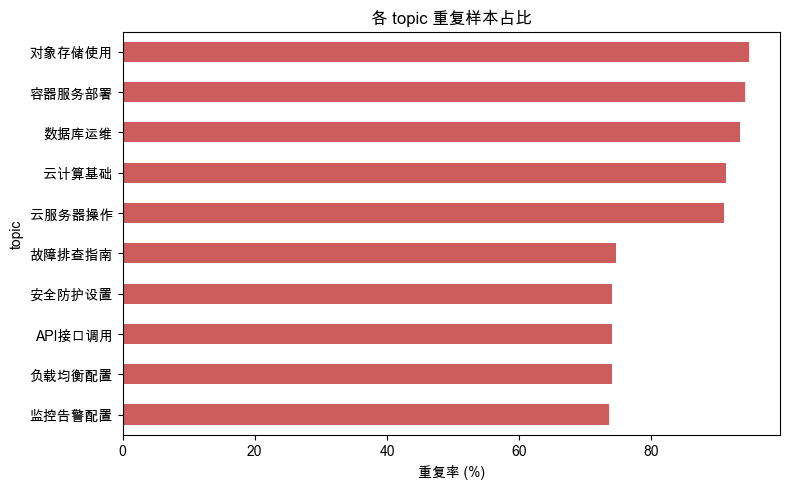

单句重复次数分布（出现次数 → 句子组数）:
2    1327
3     815
4     455
5     156
6      75
7      22
8       8
共 2858 组重复句，单句最多重复 8 次，平均 2.9 次

跨 topic 出现的重复句: 0 / 2858 组


In [8]:
# === Cell 5.1: 重复样本分布特征 ===
# 上面只回答了"重复有多少"，这里进一步回答"重复分布在哪、什么形态"：
#   1) 哪些 topic 重复最多 → 判断重复是否集中在某类技术场景
#   2) 单句重复次数分布 → 判断是少数句子被大量复制，还是普遍轻度重复
#   3) 重复句是否跨 topic → 决定 drop_duplicates 是否会破坏 topic 分布

# 1) 按 topic 统计重复样本数与重复率
dup_stat = pd.DataFrame({
    '样本总数': df.groupby('topic').size(),
    '重复样本数': df[dup_mask].groupby('topic').size(),
}).fillna(0).astype(int)
dup_stat['重复率%'] = (dup_stat['重复样本数'] / dup_stat['样本总数'] * 100).round(1)
dup_stat = dup_stat.sort_values('重复率%', ascending=False)
print(dup_stat)
print()

dup_stat['重复率%'].sort_values().plot(kind='barh', figsize=(8, 5), color='indianred')
plt.title('各 topic 重复样本占比')
plt.xlabel('重复率 (%)')
plt.tight_layout()
plt.savefig('logs/duplicate_by_topic.png', dpi=120)
plt.show()

# 2) 单句重复次数分布（每组完全相同的句对出现了几次）
rep_counts = df[dup_mask].groupby(['chinese', 'japanese', 'indonesian']).size()
print('单句重复次数分布（出现次数 → 句子组数）:')
print(rep_counts.value_counts().sort_index().to_string())
print(f'共 {len(rep_counts)} 组重复句，单句最多重复 {rep_counts.max()} 次，平均 {rep_counts.mean():.1f} 次')
print()

# 3) 同一中文句子是否跨 topic 出现
cross_topic = df[dup_mask].groupby('chinese')['topic'].nunique()
print(f'跨 topic 出现的重复句: {(cross_topic > 1).sum()} / {len(cross_topic)} 组')

# 结论（结合输出解读）：
# - 重复率明显分两档：操作/运维类 topic（对象存储使用、容器服务部署、数据库运维、
#   云计算基础、云服务器操作）高达 91-95%，配置/排查类 topic 约 74%
#   → 重复集中在操作类技术场景，说明这类场景句式模板更单一、生成多样性不足；
#     后续扩充数据时应优先补充这几类高重复 topic 的多样化句式
# - 单句重复 2-8 次、平均 2.9 次，属"普遍轻度重复"，而非少数句子被大量复制
#   → 指向数据生成阶段的全局性重复采样，扩充数据需从源头控制去重
# - 跨 topic 重复为 0 → 每组重复句 topic 完全一致，drop_duplicates 不会破坏 topic 分布，直接去重安全

In [9]:
# === Cell 6: 缺失值检查 ===
print('缺失值统计:')
print(df.isnull().sum())
print()

# 空字符串（不是 NaN，但也是问题）
for col in ['chinese', 'japanese', 'indonesian']:
    empty = (df[col].str.strip() == '').sum()
    print(f'{col} 空字符串: {empty}')

缺失值统计:


topic             0
chinese           0
japanese          0
indonesian        0
len_zh            0
len_ja            0
len_id            0
zh_ratio_in_ja    0
zh_ratio_in_id    0
ja_mixed_terms    0
ja_has_simp       0
dtype: int64

chinese 空字符串: 0
japanese 空字符串: 0
indonesian 空字符串: 0


In [10]:
# === Cell 7: 数据质量汇总报告 ===
print('=' * 50)
print('数据质量汇总')
print('=' * 50)
print(f'总样本数:          {len(df)}')
print(f'Topic 种类:        {df["topic"].nunique()}')
print(f'完全重复行:        {exact_dupes}（{len(rep_counts)} 组，单句最多 {rep_counts.max()} 次，覆盖 {dup_stat["重复样本数"].gt(0).sum()}/{len(dup_stat)} 个 topic）')
print(f'印尼语混语样本:    {id_mixed} ({id_mixed/len(df)*100:.1f}%)  [字符占比法]')
print(f'日语混语样本:      {ja_term_mixed} ({ja_term_mixed/len(df)*100:.1f}%)  [术语匹配法]')
print(f'未翻译独立术语:    {len(id_term_counter)} 个（提取自印尼语，日语残留为同一批术语）')
print(f'缺失值:            {df.isnull().sum().sum()}')
print('=' * 50)
print()
print('结论：')
print(f'1. 核心问题是术语混语（日/印尼语均 100%），已产出 {len(id_term_counter)} 个未翻译术语及频率清单 → 交给 preprocess.py 构建术语表并替换')
print(f'2. 重复覆盖全部 topic 且分两档（操作类 91-95%、配置排查类约 74%，见 Cell 5.1），跨 topic 重复 {(cross_topic > 1).sum()} 组 → drop_duplicates 不破坏 topic 分布，去重后 {len(df) - exact_dupes} 条')
print('3. 日语混语用"术语匹配 + 简体字形"双路检测（见 Cell 4.2），替换后需以同方法验证残留为 0')

数据质量汇总
总样本数:          10000
Topic 种类:        10
完全重复行:        5509（2858 组，单句最多 8 次，覆盖 10/10 个 topic）
印尼语混语样本:    10000 (100.0%)  [字符占比法]
日语混语样本:      10000 (100.0%)  [术语匹配法]
未翻译独立术语:    35 个（提取自印尼语，日语残留为同一批术语）
缺失值:            0

结论：
1. 核心问题是术语混语（日/印尼语均 100%），已产出 35 个未翻译术语及频率清单 → 交给 preprocess.py 构建术语表并替换
2. 重复覆盖全部 topic 且分两档（操作类 91-95%、配置排查类约 74%，见 Cell 5.1），跨 topic 重复 0 组 → drop_duplicates 不破坏 topic 分布，去重后 4491 条
3. 日语混语用"术语匹配 + 简体字形"双路检测（见 Cell 4.2），替换后需以同方法验证残留为 0
